LISTA 4 - PROCESY POISSONA

In [ ]:
import numpy as np
import math as m


import matplotlib.pyplot as plt
import scipy.stats as sc

In [3]:
def S_n1(T, lam=2):
    S_n = []
    t = 0
    I = 0
    while True:
        U = np.random.random()
        dt = -1/lam * m.log(U)
        t += dt
        if t > T:
            break
        S_n.append(t)
    return np.array(S_n)

def S_n2(T, lam=2):
    n = np.random.poisson(lam=lam*T)
    if n == 0:
        return np.array([])
    U = np.random.uniform(high=T, size=n)
    S_n = np.sort(U)
    return np.array(S_n)

def N_t(S_n, t):
    return np.sum(S_n <= t)

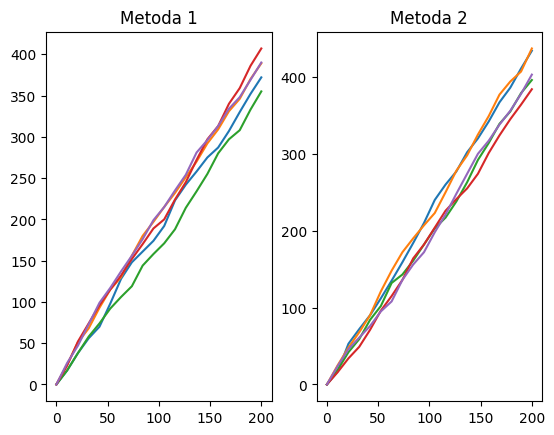

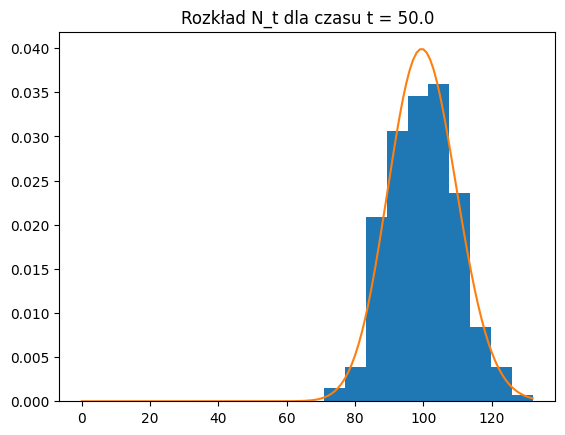

Wartości średnie 99.98, 100.0, wariancje: 95.7, 100.0


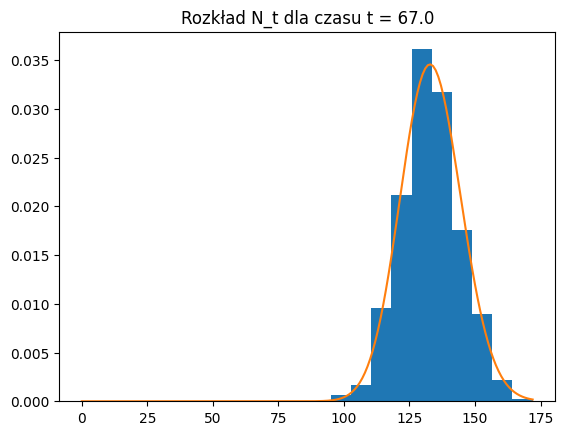

Wartości średnie 132.88, 133.0, wariancje: 126.09, 133.0


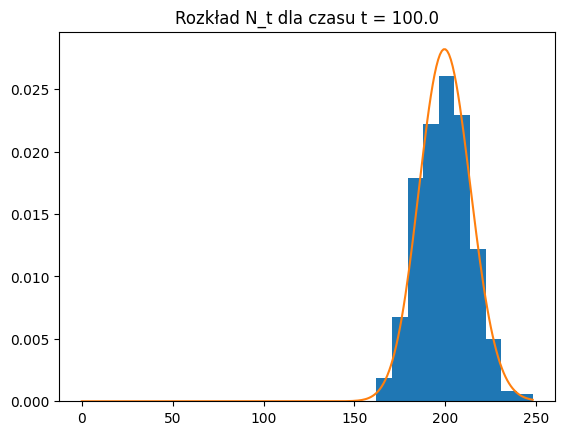

Wartości średnie 199.32, 200.0, wariancje: 200.73, 200.0


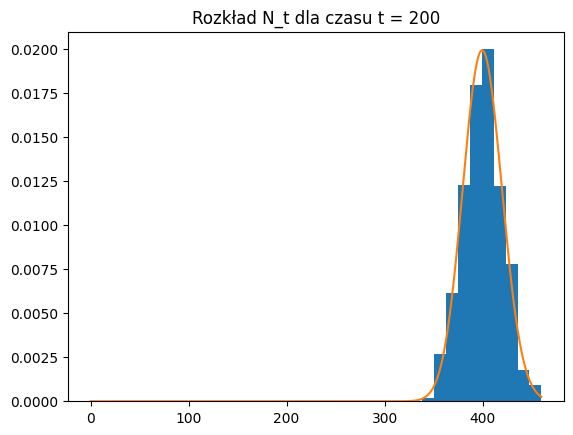

Wartości średnie 399.59, 400, wariancje: 406.37, 400


In [4]:
T = 200
n = 20
lam = 2
Poiss1 = S_n1(T, lam)
Poiss2 = S_n2(T, lam)
t = np.linspace(0, T, n)
traj_1 = np.empty(n)
traj_2 = np.empty(n)

fig, ax = plt.subplots(1, 2)
for k in range(5):
    Poiss1 = S_n1(T, lam)
    Poiss2 = S_n2(T, lam)
    traj1 = [N_t(Poiss1, ti) for ti in t]
    traj2 = [N_t(Poiss2, ti) for ti in t]
    ax[0].plot(t, traj1, label='Trajektoria {k}')
    ax[0].set_title('Metoda 1')
    ax[1].plot(t, traj2, label='Trajektoria {k}')
    ax[1].set_title('Metoda 2')
plt.show()

list_of_T = [T/4, T/3, T/2, T]
nt_list = [[], [], [], []]
N = 1000
s = []
for k in range(N):
    s.append(S_n2(T, lam))

for i in range(4):
    for element in s:
        nt_list[i].append(N_t(element, list_of_T[i]))

for i in range(len(list_of_T)):
    x = np.arange(0, max(nt_list[i]) + 1)
    y = sc.poisson.pmf(x, lam*list_of_T[i])
    plt.hist(nt_list[i],density=True)
    plt.title(f"Rozkład N_t dla czasu t = {np.round(list_of_T[i])}")
    plt.plot(x, y, label='Probability density mass function')
    plt.show()
    var_theory = lam*list_of_T[i]
    mean_theory = var_theory
    var_real = np.var(nt_list[i])
    mean_real = np.mean(nt_list[i])
    print(f'Wartości średnie {np.round(mean_real, 2)}, {np.round(mean_theory)}, wariancje: {np.round(var_real, 2)}, {np.round(var_theory)}')

In [5]:
def poisson_deviation(N_t, t, lam):
    return N_t - t * lam

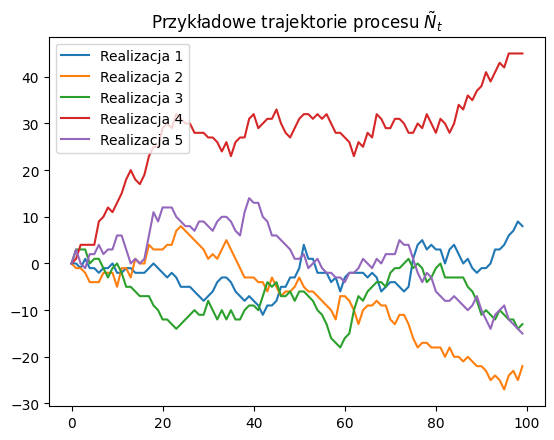

Wariancja w realizacji: 29.87, wariancja teoretyczna: 30.0, wartość średnia = 0.0426
Wariancja w realizacji: 97.82, wariancja teoretyczna: 97.5, wartość średnia = -0.0106
Wariancja w realizacji: 167.41, wariancja teoretyczna: 165.0, wartość średnia = -0.1681
Wariancja w realizacji: 237.89, wariancja teoretyczna: 232.5, wartość średnia = -0.2081
Wariancja w realizacji: 309.44, wariancja teoretyczna: 300.0, wartość średnia = -0.1676


In [6]:
lam = 3
T = 100
t = np.arange(0, T, 1)
for k in range(5):
    poiss = S_n1(T, lam=lam)
    traj = [N_t(poiss, ti) for ti in t]
    plt.plot(t, poisson_deviation(traj, t, lam=lam), label=f'Realizacja {k+1}')
    
plt.title(r"Przykładowe trajektorie procesu $\tilde{N}_t$")
plt.legend()
plt.show()

t_k = np.linspace(10, T, 5)
N = 10000
results = [[] for _ in t_k]
var_theory = []

for _ in range(N):
    S = S_n1(T, lam)
    
    for i, t in enumerate(t_k):
        N_tilde = poisson_deviation(N_t(S, t), t, lam)
        var_theory.append(lam*t)
        results[i].append(N_tilde)
    
for i in range(len(results)):
    r = results[i]
    vt = var_theory[i]
    print(f'Wariancja w realizacji: {np.round(np.var(r), 2)}, wariancja teoretyczna: {np.round(vt, 2)}, wartość średnia = {np.mean(r)}')


# Wartości teoretyczne

Interesuje nas $ E[\tilde{N_t}]$ i $ Var[\tilde{N_t}] $

Własność liniowości wartości oczekiwanej:

$ E[\tilde{N_t}] = E[N_t - \lambda t] = E[N_t] - E[\lambda t] = 0$

$\lambda t$ nie jest zmienną losową, zatem mamy:

$ Var[\tilde{N_t}] = Var[N_t - \lambda t]= Var[N_t] = \lambda t$

## 3. Własności martyngału

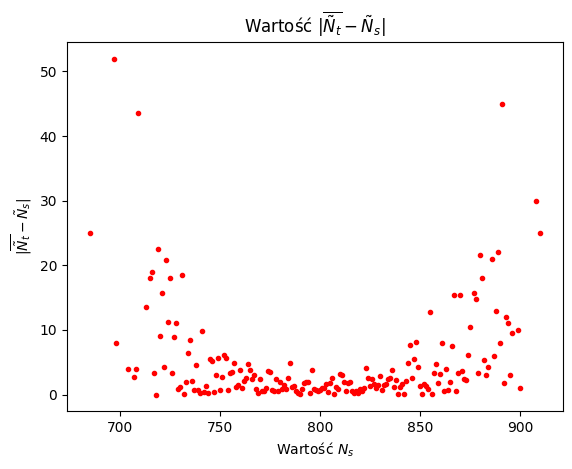

In [7]:
T = 200
s = 100
t = 160
N = 10000
lam = 8

pairs = []

for i in range(N):
    S = S_n1(T, lam)
    Ns = N_t(S, s)
    Nt = N_t(S, t)
    pairs.append((Ns, Nt - lam*t))

groups = {}
for Ns, Ntilde_t in pairs:
    if Ns not in groups:
        groups[Ns] = []
    groups[Ns].append(Ntilde_t)


x = []
y = []
for group in groups:
    values = groups[group]
    mean_ntilde = np.mean(values)
    diff = np.abs(mean_ntilde - (group - lam*s))
    x.append(group)
    y.append(diff)

plt.plot(x, y, 'ro', markersize=3)
plt.xlabel(r"Wartość $N_s$")
plt.ylabel(r"$|\overline{\tilde{N}_t} - \tilde{N}_s|$")
plt.title(r"Wartość $|\overline{\tilde{N}_t} - \tilde{N}_s|$")
plt.show()

### Generator rozkładu Posissona

1. Meoda iloczynu zmiennych
2. Metoda rozkładu Gamma

In [8]:
def poisson1(lam):
    n = 0
    a = 1
    while True:
        U = np.random.random()
        a *= U
        if a > np.exp(-lam):
            n += 1
        else:
            return n

def poisson2(lam):
    if lam < 10:
        return poisson1(lam)
    
    m = int(np.floor(7/8 * lam))
    Y = np.random.gamma(m, 1)

    if Y <= lam:
        Z = poisson2(lam - Y)
        X = m + Z
        return X
    
    return np.random.binomial(m - 1, lam / Y)

Wartości średnie: oczekiwana: 3.5, faktyczna: 3.5 
Wariancje: oczekiwana: 3.5, faktyczna: 3.5
P-value: 1.0
Wartości średnie: oczekiwana: 6.3, faktyczna: 6.3 
Wariancje: oczekiwana: 6.3, faktyczna: 6.27
P-value: 1.0
Wartości średnie: oczekiwana: 15, faktyczna: 15.0 
Wariancje: oczekiwana: 15, faktyczna: 14.98
P-value: 1.0
Wartości średnie: oczekiwana: 21, faktyczna: 20.98 
Wariancje: oczekiwana: 21, faktyczna: 20.94
P-value: 1.0
Wartości średnie: oczekiwana: 30, faktyczna: 30.01 
Wariancje: oczekiwana: 30, faktyczna: 30.03
P-value: 1.0
Wartości średnie: oczekiwana: 40, faktyczna: 40.02 
Wariancje: oczekiwana: 40, faktyczna: 39.96
P-value: 1.0


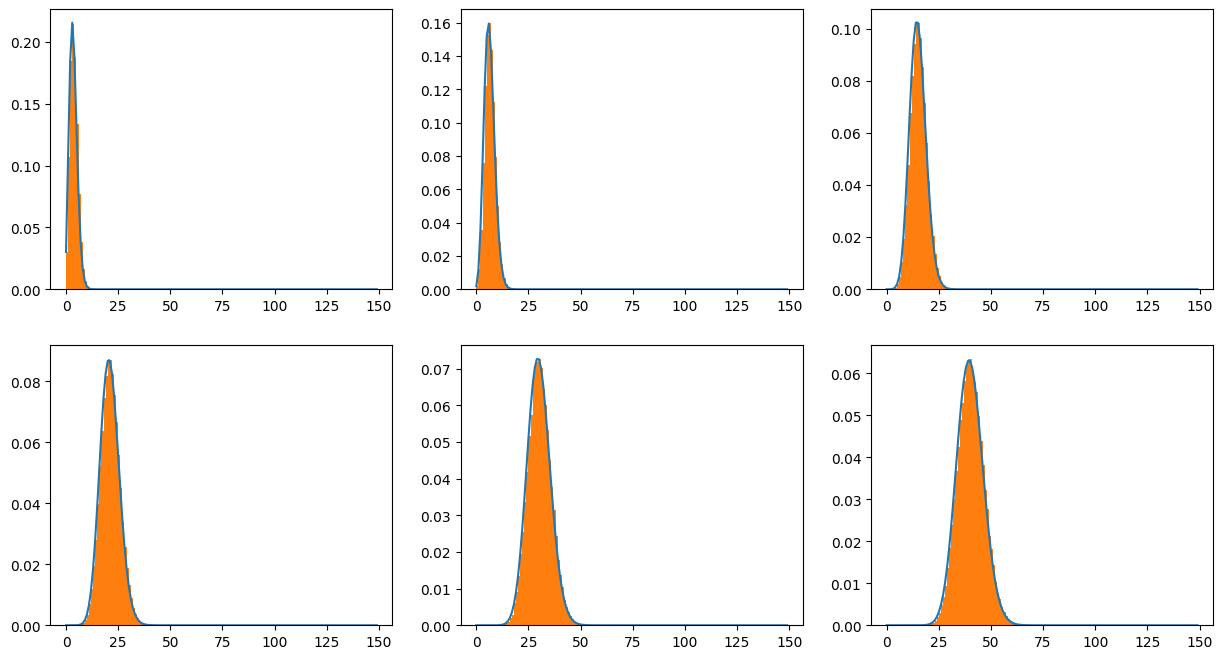

In [9]:
N = 100000
lam_list = [3.5, 6.3, 15, 21, 30, 40]
k = np.arange(0, 150, 1)

fig, ax = plt.subplots(2, 3,figsize=(15, 8))

for i in range(2):
    for g in range(3):
        lam = lam_list[3*i+g]
        ax[i, g].plot(k, sc.poisson.pmf(k, mu = lam))
        poiss = np.arange(N)

        for h in range(N):
            poiss[h] = poisson2(lam=lam)

        ax[i, g].hist(poiss, bins=np.arange(0, 150), density=True)
        print(f'Wartości średnie: oczekiwana: {lam}, faktyczna: {np.round(np.mean(poiss), 2)} ')
        print(f'Wariancje: oczekiwana: {lam}, faktyczna: {np.round(np.var(poiss), 2)}')
        observed_values, counts = np.unique(poiss, return_counts=True)
        real_values = []
    
        ind = 0
        expected_counts = N * sc.poisson.pmf(k, mu=lam)

        for value in k:
            if ind < len(observed_values) and observed_values[ind] == value:
                real_values.append(counts[ind])
                ind += 1
            else:
                real_values.append(0)

        expected_counts = expected_counts * (sum(real_values) / sum(expected_counts)) # skalowanie wartości aby zapobiec niepoprawnej wartosci E_counts
        statistic, p_value = sc.chisquare(f_obs=real_values, f_exp=expected_counts,)
        print(f'P-value: {round(p_value, 4)}')
        